# Makine Öğrenmesi Tabanlı Ağ Anomali Tespiti

## CSE-CIC-IDS2018 Veri Seti Üzerinde Random Forest ve XGBoost Karşılaştırması

Bu notebook, CSE-CIC-IDS2018 veri seti kullanılarak ağ trafiğinin **normal trafik** ve **saldırı trafiği** olarak sınıflandırılması amacıyla hazırlanmıştır. Çalışmada makine öğrenmesi tabanlı ağ anomali tespiti problemi binary classification yaklaşımıyla ele alınmıştır.

Çalışmanın temel amacı, modern ağ trafiği içinde yer alan saldırı örüntülerini makine öğrenmesi yöntemleriyle tespit etmek ve iki topluluk öğrenme algoritmasının performansını karşılaştırmaktır.

Karşılaştırılan modeller:

- Random Forest
- XGBoost

Değerlendirme metrikleri:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Bu notebook, proje raporunun deneysel çalışma kısmını desteklemek üzere hazırlanmıştır. Üretilen tablo ve grafikler `outputs` klasörüne kaydedilir.

## 1. Proje Klasör Yapısı

Notebook, bilgisayara özel mutlak dosya yolu kullanmadan çalışacak şekilde tasarlanmıştır. Veri seti, notebook ile aynı proje klasörü altında bulunan `data/MachineLearningCSV` klasöründen okunur.

Beklenen klasör yapısı:

```text
CSE-CIC-IDS2018/
│
├── ag_anomali_tespiti_final_teslim.ipynb
│
├── data/
│   └── MachineLearningCSV/
│       ├── 02-14-2018.csv
│       ├── 02-15-2018.csv
│       ├── 02-16-2018.csv
│       ├── 02-20-2018.csv
│       ├── 02-21-2018.csv
│       ├── 02-22-2018.csv
│       ├── 02-23-2018.csv
│       ├── 02-28-2018.csv
│       ├── 03-01-2018.csv
│       └── 03-02-2018.csv
│
├── files/
│   ├── Rapor_1.pdf
│   ├── Rapor_2.pdf
│   ├── Sunum_1.pdf
│   ├── Sunum_2.pdf
│   ├── Literatur_Cizelge.xlsx
│   └── ESOGUmmfSABLON.docx.pdf
│
└── outputs/
```

CSV dosyaları büyük boyutlu olduğu için GitHub deposuna doğrudan yüklenmemesi önerilir. Veri seti klasörü proje kökünde aynı yapıyla tutulduğunda notebook farklı bilgisayarlarda da çalıştırılabilir.

## 2. Deneysel Tasarım

Bu çalışmada problem binary classification olarak modellenmiştir.

Sınıf tanımları:

- `BENIGN`: Normal ağ trafiği
- `ATTACK`: BENIGN dışındaki tüm saldırı türleri

Bu yaklaşım, ağ anomali tespitinde ilk aşama için uygundur. Çünkü gerçek sistemlerde öncelikli hedef, trafiğin normal mi yoksa şüpheli/saldırı davranışı mı gösterdiğini belirlemektir.

Deneysel süreç şu adımlardan oluşur:

1. CSV dosyalarının okunması
2. Veri temizleme
3. Tekrarlı başlık satırlarının temizlenmesi
4. Gereksiz/tanımlayıcı sütunların çıkarılması
5. Binary etiket dönüşümü
6. Eksik ve sonsuz değerlerin işlenmesi
7. Train-test ayrımı
8. Ölçeklendirme
9. Öznitelik seçimi
10. Random Forest model eğitimi
11. XGBoost model eğitimi
12. Performans karşılaştırması
13. Bulguların tablo ve grafik olarak kaydedilmesi

## 3. Kütüphaneler ve Genel Ayarlar

Bu bölümde veri işleme, modelleme, metrik hesaplama ve görselleştirme için gerekli kütüphaneler yüklenir.

In [33]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

## 4. Proje Yolları

Proje kökü, notebookun çalıştırıldığı klasör olarak kabul edilir. Veri klasörü ve çıktı klasörü bu proje köküne göre tanımlanır.

In [34]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "MachineLearningCSV"
FILES_DIR = PROJECT_ROOT / "files"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Veri klasörü bulunamadı: {DATA_DIR}\n"
        "CSV dosyalarını data/MachineLearningCSV klasörüne yerleştiriniz."
    )

csv_files = sorted(DATA_DIR.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"{DATA_DIR} içinde CSV dosyası bulunamadı."
    )

print("Proje kökü:", PROJECT_ROOT)
print("Veri klasörü:", DATA_DIR)
print("Çıktı klasörü:", OUTPUT_DIR)
print("Bulunan CSV dosyası sayısı:", len(csv_files))

for csv_file in csv_files:
    print("-", csv_file.name)

Proje kökü: c:\Users\Asus\Desktop\CSE-CIC-IDS2018
Veri klasörü: c:\Users\Asus\Desktop\CSE-CIC-IDS2018\data\MachineLearningCSV
Çıktı klasörü: c:\Users\Asus\Desktop\CSE-CIC-IDS2018\outputs
Bulunan CSV dosyası sayısı: 10
- 02-14-2018.csv
- 02-15-2018.csv
- 02-16-2018.csv
- 02-20-2018.csv
- 02-21-2018.csv
- 02-22-2018.csv
- 02-23-2018.csv
- 02-28-2018.csv
- 03-01-2018.csv
- 03-02-2018.csv


## 5. Veri Okuma Stratejisi

CSE-CIC-IDS2018 veri seti büyük boyutlu olduğu için notebook iki okuma modunu destekler.

- `READ_MODE = "sample"`: Her CSV dosyasından belirli sayıda kayıt örneklenir.
- `READ_MODE = "full"`: CSV dosyalarının tamamı okunur.

Bu çalışmada bilgisayar kaynaklarını verimli kullanmak için varsayılan olarak `sample` modu kullanılır. Örnekleme sırasında `random_state` sabit tutulduğu için sonuçlar aynı ortamda tekrar üretilebilir.

In [35]:
READ_MODE = "sample"     # "sample" veya "full"
SAMPLE_PER_FILE = 50000  # sample modunda her dosyadan alınacak maksimum kayıt sayısı

def read_single_csv(file_path: Path, read_mode: str, sample_per_file: int) -> pd.DataFrame:
    data = pd.read_csv(file_path, low_memory=False)
    data.columns = data.columns.str.strip()

    if read_mode == "sample" and len(data) > sample_per_file:
        data = data.sample(n=sample_per_file, random_state=RANDOM_STATE)

    data["source_file"] = file_path.name
    return data

dataframes = []
start_time = time.time()

for file_path in csv_files:
    print(f"Okunuyor: {file_path.name}")
    part = read_single_csv(file_path, READ_MODE, SAMPLE_PER_FILE)
    print(f"  Satır: {part.shape[0]:,} | Sütun: {part.shape[1]:,}")
    dataframes.append(part)

df_raw = pd.concat(dataframes, ignore_index=True)
elapsed = time.time() - start_time

print("\nVeri okuma tamamlandı.")
print("Toplam satır:", f"{df_raw.shape[0]:,}")
print("Toplam sütun:", f"{df_raw.shape[1]:,}")
print("Süre:", f"{elapsed:.2f} saniye")

Okunuyor: 02-14-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-15-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-16-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-20-2018.csv
  Satır: 50,000 | Sütun: 85
Okunuyor: 02-21-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-22-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-23-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 02-28-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 03-01-2018.csv
  Satır: 50,000 | Sütun: 81
Okunuyor: 03-02-2018.csv
  Satır: 50,000 | Sütun: 81

Veri okuma tamamlandı.
Toplam satır: 500,000
Toplam sütun: 85
Süre: 176.85 saniye


## 6. İlk Veri İncelemesi

Bu bölümde veri setinin genel yapısı, sütun adları, veri tipleri ve etiket dağılımı incelenir. Etiket sütunu otomatik olarak belirlenir.

In [36]:
display(df_raw.head())
print("Veri boyutu:", df_raw.shape)
print("\nSütunlar:")
for column in df_raw.columns:
    print("-", column)

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file,Flow ID,Src IP,Src Port,Dst IP
0,53,17,14/02/2018 08:44:26,36517,2,2,80,204,40,40,40.000000,0.000000,102,102,102.000000,0.000000,7777.199660,109.538023,12172.333333,14594.074151,28512,432,36085,36085.000000,0.000000,36085,36085,8005,8005.000000,0.000000,8005,8005,0,0,0,0,16,16,54.769012,54.769012,40,102,64.800000,33.958799,1153.200000,0,0,0,0,0,0,0,0,1,81.000000,40.000000,102.000000,0,0,0,0,0,0,2,80,2,204,-1,-1,1,8,0.000000,0.000000,0,0,0.000000,0.000000,0,0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
1,49906,6,14/02/2018 09:31:42,51,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,39215.686275,51.000000,0.000000,51,51,0,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0,0,0,0,0,20,20,19607.843137,19607.843137,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,0.000000,0.000000,0.000000,0,0,0,0,0,0,1,0,1,0,513,255,0,20,0.000000,0.000000,0,0,0.000000,0.000000,0,0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
2,80,6,14/02/2018 04:13:41,53514166,2,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.037373,53514166.000000,0.000000,53514166,53514166,53514166,53514166.000000,0.000000,53514166,53514166,0,0.000000,0.000000,0,0,0,0,0,0,40,0,0.037373,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,2,0,0,0,279,-1,0,20,0.000000,0.000000,0,0,0.000000,0.000000,0,0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
3,443,6,14/02/2018 11:05:34,272,3,0,77,0,46,0,25.666667,23.459184,0,0,0.000000,0.000000,283088.235294,11029.411765,136.000000,158.391919,248,24,272,136.000000,158.391919,248,24,0,0.000000,0.000000,0,0,1,0,0,0,60,0,11029.411765,0.000000,0,46,30.750000,21.685248,470.250000,0,1,0,0,1,0,0,0,0,41.000000,25.666667,0.000000,0,0,0,0,0,0,3,77,0,0,258,-1,1,20,0.000000,0.000000,0,0,0.000000,0.000000,0,0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN
4,53,17,14/02/2018 03:23:23,1219,1,1,40,100,40,40,40.000000,0.000000,100,100,100.000000,0.000000,114848.236259,1640.689089,1219.000000,0.000000,1219,1219,0,0.000000,0.000000,0,0,0,0.000000,0.000000,0,0,0,0,0,0,8,8,820.344545,820.344545,40,100,60.000000,34.641016,1200.000000,0,0,0,0,0,0,0,0,1,90.000000,40.000000,100.000000,0,0,0,0,0,0,1,40,1,100,-1,-1,0,8,0.000000,0.000000,0,0,0.000000,0.000000,0,0,Benign,02-14-2018.csv,NaN,NaN,NaN,NaN


Veri boyutu: (500000, 85)

Sütunlar:
- Dst Port
- Protocol
- Timestamp
- Flow Duration
- Tot Fwd Pkts
- Tot Bwd Pkts
- TotLen Fwd Pkts
- TotLen Bwd Pkts
- Fwd Pkt Len Max
- Fwd Pkt Len Min
- Fwd Pkt Len Mean
- Fwd Pkt Len Std
- Bwd Pkt Len Max
- Bwd Pkt Len Min
- Bwd Pkt Len Mean
- Bwd Pkt Len Std
- Flow Byts/s
- Flow Pkts/s
- Flow IAT Mean
- Flow IAT Std
- Flow IAT Max
- Flow IAT Min
- Fwd IAT Tot
- Fwd IAT Mean
- Fwd IAT Std
- Fwd IAT Max
- Fwd IAT Min
- Bwd IAT Tot
- Bwd IAT Mean
- Bwd IAT Std
- Bwd IAT Max
- Bwd IAT Min
- Fwd PSH Flags
- Bwd PSH Flags
- Fwd URG Flags
- Bwd URG Flags
- Fwd Header Len
- Bwd Header Len
- Fwd Pkts/s
- Bwd Pkts/s
- Pkt Len Min
- Pkt Len Max
- Pkt Len Mean
- Pkt Len Std
- Pkt Len Var
- FIN Flag Cnt
- SYN Flag Cnt
- RST Flag Cnt
- PSH Flag Cnt
- ACK Flag Cnt
- URG Flag Cnt
- CWE Flag Count
- ECE Flag Cnt
- Down/Up Ratio
- Pkt Size Avg
- Fwd Seg Size Avg
- Bwd Seg Size Avg
- Fwd Byts/b Avg
- Fwd Pkts/b Avg
- Fwd Blk Rate Avg
- Bwd Byts/b Avg
- Bwd Pkts/b A

In [37]:
candidate_label_columns = ["Label", "label", "Attack", "attack", "Class", "class"]

label_column = None

for candidate in candidate_label_columns:
    if candidate in df_raw.columns:
        label_column = candidate
        break

if label_column is None:
    raise ValueError(
        "Etiket sütunu bulunamadı. Veri setinde Label benzeri bir hedef sütun olmalıdır."
    )

print("Etiket sütunu:", label_column)

Etiket sütunu: Label


,count
Label,
Benign,380298
DDOS attack-HOIC,32860
DoS attacks-Hulk,22053
Infilteration,19793
Bot,13764
FTP-BruteForce,9305
SSH-Bruteforce,9016
DoS attacks-SlowHTTPTest,6721
DDoS attacks-LOIC-HTTP,3580


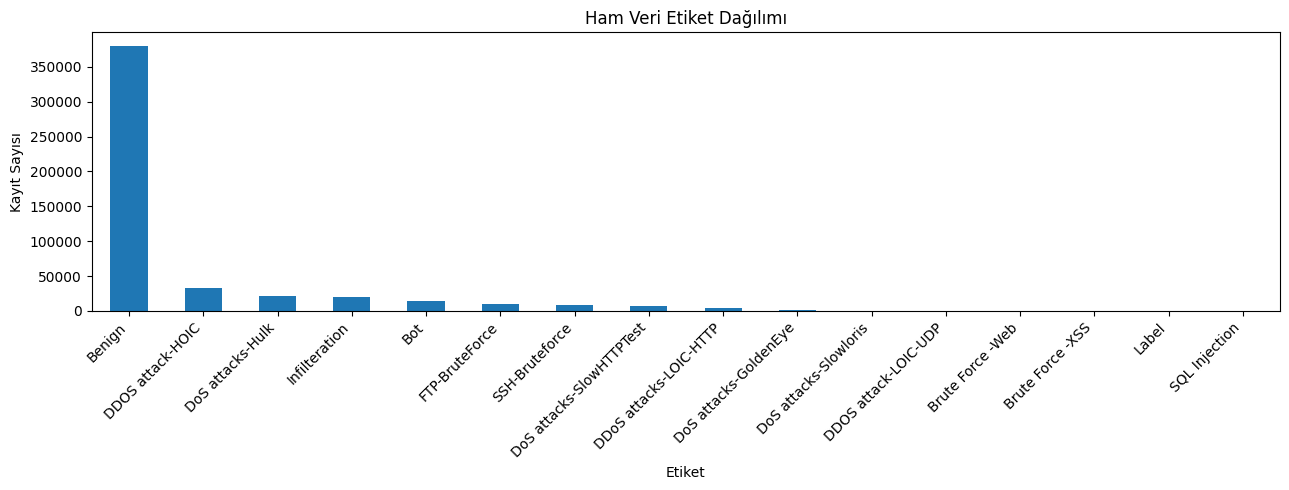

In [38]:
raw_label_counts = df_raw[label_column].astype(str).str.strip().value_counts(dropna=False)

display(raw_label_counts.to_frame("count"))
raw_label_counts.to_csv(OUTPUT_DIR / "raw_label_distribution.csv", encoding="utf-8-sig")

plt.figure(figsize=(13, 5))
raw_label_counts.plot(kind="bar")
plt.title("Ham Veri Etiket Dağılımı")
plt.xlabel("Etiket")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "raw_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Veri Temizleme

Veri temizleme aşamasında şu işlemler yapılır:

- Sütun adları düzenlenir.
- CSV dosyalarının içinde veri satırı gibi okunmuş tekrar eden başlık satırları temizlenir.
- Duplicate satırlar kaldırılır.
- Sonsuz değerler `NaN` olarak işaretlenir.
- Modelin ezberleme yapmasına neden olabilecek tanımlayıcı sütunlar çıkarılır.

Özellikle `Flow ID`, IP adresleri ve `Timestamp` gibi alanlar model girdisinden çıkarılır. Bu alanlar gerçek trafik davranışından ziyade veri setine özgü kimlik bilgileri taşıyabilir.

In [39]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

initial_row_count = len(df)

# CSV içinde tekrar eden başlık satırları varsa temizlenir.
df = df[df[label_column].astype(str).str.strip().str.lower() != label_column.lower()]

removed_repeated_headers = initial_row_count - len(df)
print("Temizlenen tekrar başlık satırı sayısı:", removed_repeated_headers)

before_duplicates = len(df)
df = df.drop_duplicates()
after_duplicates = len(df)

print("Silinen duplicate satır sayısı:", before_duplicates - after_duplicates)

df = df.replace([np.inf, -np.inf], np.nan)

missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

print("Eksik değer içeren sütun sayısı:", len(missing_summary))
display(missing_summary.to_frame("missing_count").head(30))

missing_summary.to_csv(OUTPUT_DIR / "missing_values_summary.csv", encoding="utf-8-sig")

Temizlenen tekrar başlık satırı sayısı: 9
Silinen duplicate satır sayısı: 4960
Eksik değer içeren sütun sayısı: 6


,missing_count
Src IP,445031
Flow ID,445031
Src Port,445031
Dst IP,445031
Flow Byts/s,2301
Flow Pkts/s,1682


In [40]:
identifier_keywords = [
    "flow id",
    "src ip",
    "dst ip",
    "source ip",
    "destination ip",
    "timestamp",
    "time stamp"
]

columns_to_drop = []

for column in df.columns:
    normalized_column = column.lower().strip()

    if normalized_column == "source_file":
        columns_to_drop.append(column)
    elif any(keyword in normalized_column for keyword in identifier_keywords):
        columns_to_drop.append(column)

columns_to_drop = sorted(set(columns_to_drop))

print("Model girdisinden çıkarılacak sütunlar:")
for column in columns_to_drop:
    print("-", column)

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Temizleme sonrası veri boyutu:", df.shape)

Model girdisinden çıkarılacak sütunlar:
- Dst IP
- Flow ID
- Src IP
- Timestamp
- source_file
Temizleme sonrası veri boyutu: (495031, 80)


## 8. Binary Etiket Dönüşümü

CSE-CIC-IDS2018 veri setinde saldırılar farklı alt sınıflarla etiketlenmiştir. Bu çalışmada tüm saldırı türleri tek bir `ATTACK` sınıfı altında birleştirilir.

Dönüşüm:

- `BENIGN` → `0`
- BENIGN dışındaki tüm etiketler → `1`

,count
BENIGN,380233
ATTACK,114798


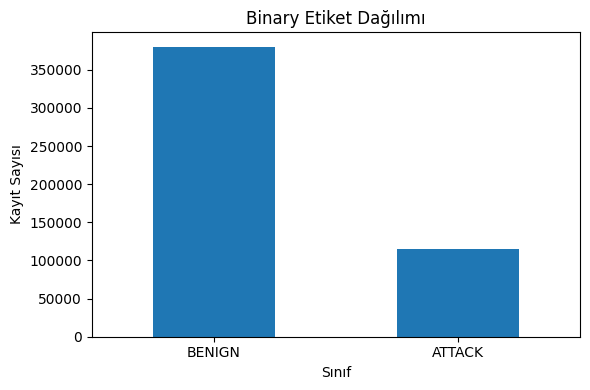

BENIGN / ATTACK oranı: 3.31


In [41]:
def normalize_label(value) -> str:
    return str(value).strip().upper()

df["binary_label"] = df[label_column].apply(
    lambda value: 0 if normalize_label(value) == "BENIGN" else 1
)

binary_counts = df["binary_label"].value_counts().sort_index()
binary_counts.index = ["BENIGN", "ATTACK"]

display(binary_counts.to_frame("count"))
binary_counts.to_csv(OUTPUT_DIR / "binary_label_distribution.csv", encoding="utf-8-sig")

plt.figure(figsize=(6, 4))
binary_counts.plot(kind="bar")
plt.title("Binary Etiket Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "binary_label_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

benign_count = int(binary_counts.loc["BENIGN"])
attack_count = int(binary_counts.loc["ATTACK"])
imbalance_ratio = benign_count / attack_count if attack_count > 0 else np.nan

print(f"BENIGN / ATTACK oranı: {imbalance_ratio:.2f}")

## 9. Özellik Matrisi ve Hedef Değişken

Bu bölümde hedef değişken ayrılır. Sayısal olmayan sütunlar `LabelEncoder` ile sayısallaştırılır. Eksik değerler, eğitim algoritmalarının hata vermemesi için medyan değerlerle doldurulur.

In [42]:
target_columns = [label_column, "binary_label"]

X = df.drop(columns=target_columns, errors="ignore")
y = df["binary_label"].astype(int)

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Sayısal sütun sayısı:", len(numeric_columns))
print("Kategorik sütun sayısı:", len(categorical_columns))

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column].astype(str))

X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

missing_before_fill = int(X.isna().sum().sum())
print("Doldurma öncesi eksik değer sayısı:", missing_before_fill)

X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

missing_after_fill = int(X.isna().sum().sum())
print("Doldurma sonrası eksik değer sayısı:", missing_after_fill)

print("Özellik matrisi boyutu:", X.shape)
print("Hedef vektör boyutu:", y.shape)

Sayısal sütun sayısı: 1
Kategorik sütun sayısı: 78
Doldurma öncesi eksik değer sayısı: 445031
Doldurma sonrası eksik değer sayısı: 0
Özellik matrisi boyutu: (495031, 79)
Hedef vektör boyutu: (495031,)


## 10. Eğitim ve Test Ayrımı

Veri seti %80 eğitim, %20 test olacak şekilde ayrılır. `stratify=y` parametresi kullanılarak sınıf oranlarının eğitim ve test setlerinde korunması sağlanır.

Test seti gerçek dağılımı temsil etmelidir. Bu nedenle sınıf dengeleme veya örnek artırma işlemleri test setine uygulanmaz.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

train_distribution = y_train.value_counts().sort_index().rename(index={0: "BENIGN", 1: "ATTACK"})
test_distribution = y_test.value_counts().sort_index().rename(index={0: "BENIGN", 1: "ATTACK"})

print("\nEğitim seti dağılımı:")
display(train_distribution.to_frame("count"))

print("\nTest seti dağılımı:")
display(test_distribution.to_frame("count"))

X_train: (396024, 79)
X_test : (99007, 79)

Eğitim seti dağılımı:


,count
binary_label,
BENIGN,304186
ATTACK,91838



Test seti dağılımı:


,count
binary_label,
BENIGN,76047
ATTACK,22960


## 11. Ölçeklendirme

Ağaç tabanlı modeller ölçeklendirmeye zorunlu olarak ihtiyaç duymaz. Ancak öznitelik seçimi aşamasında daha kontrollü sayısal aralık sağlamak için Min-Max ölçeklendirme uygulanır.

Veri sızıntısını önlemek için ölçekleyici yalnızca eğitim verisi üzerinde öğrenilir.

In [44]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Src Port
192853,0.602900,0.500000,0.201029,0.000000,0.001493,0.607418,0.063957,0.476651,0.393939,0.484937,0.000038,0.113355,0.081749,0.079425,0.000039,0.065697,0.461010,0.134195,0.000004,0.158576,0.113238,0.000014,0.000013,0.000005,0.000005,0.000037,0.000006,0.000006,0.000006,0.000008,0.000013,0.000000,0.000000,0.000000,0.000000,0.892704,0.907013,0.937243,0.938552,0.347826,0.116082,0.847623,0.610465,0.400622,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050847,0.989194,0.490427,0.080334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.595864,0.001493,0.071556,0.000000,0.000000,0.000000,1.000000,0.000023,0.000033,0.000023,0.000032,0.000020,0.000030,0.000022,0.000020,0.863020
317577,0.528350,1.000000,0.532718,0.000000,0.001493,0.000000,0.000000,0.000000,0.000000,0.000056,0.000038,0.000000,0.000000,0.000045,0.000039,0.000004,0.797207,0.553142,0.000004,0.449350,0.493613,0.000010,0.000013,0.000005,0.000000,0.000024,0.000000,0.000006,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.310086,0.323089,0.581351,0.584804,0.000000,0.000000,0.000031,0.000027,0.000028,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.033898,0.000033,0.000058,0.000045,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001493,0.000000,0.139384,0.268602,0.000000,0.125000,0.000023,0.000033,0.000000,0.000000,0.000020,0.000030,0.000000,0.000000,0.799512
71870,0.602900,0.500000,0.318502,0.000000,0.001493,0.556083,0.826984,0.440050,0.341991,0.448191,0.000038,0.790228,0.885932,0.864086,0.000039,0.653602,0.996562,0.311379,0.000004,0.265123,0.242623,0.000010,0.000013,0.000005,0.000000,0.000024,0.000000,0.000006,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.892704,0.907013,0.806338,0.810789,0.293478,0.777463,0.742720,0.094083,0.731322,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033898,0.865467,0.453460,0.863114,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.538245,0.001493,0.817504,0.000000,0.000000,0.000000,1.000000,0.000023,0.000033,0.000000,0.000000,0.000020,0.000030,0.000000,0.000000,0.799512
40843,0.496001,1.000000,0.310059,0.589065,0.000000,0.528932,0.000000,0.421960,0.000000,0.015428,0.314984,0.000000,0.000000,0.000045,0.000039,0.230902,0.477385,0.000035,0.000048,0.255967,0.000031,0.289329,0.000043,0.000060,0.368895,0.000024,0.000000,0.000006,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.759657,0.000000,0.464085,0.000005,0.000000,0.450736,0.877893,0.043903,0.441254,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.002481,0.015686,0.000045,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589065,0.509737,0.000000,0.000000,0.376661,0.000000,0.004386,0.125000,0.000023,0.000033,0.000000,0.000000,0.000020,0.000030,0.000000,0.000000,0.799512
446607,0.602900,0.500000,0.481622,0.391534,0.26716

## 12. Öznitelik Seçimi

Veri setinde çok sayıda ağ trafiği özniteliği bulunmaktadır. Tüm özniteliklerin modele verilmesi hesaplama maliyetini artırabilir ve bazı durumlarda genelleme başarısını düşürebilir.

Bu çalışmada Mutual Information yöntemiyle hedef değişkenle ilişkisi yüksek olan öznitelikler seçilmiştir. Varsayılan olarak en iyi 20 öznitelik kullanılır.

In [45]:
TOP_K_FEATURES = 20

start_time = time.time()

mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=RANDOM_STATE
)

feature_scores = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

selected_features = feature_scores.head(TOP_K_FEATURES)["feature"].tolist()

elapsed = time.time() - start_time

print(f"Öznitelik seçimi tamamlandı. Süre: {elapsed:.2f} saniye")
print("Seçilen öznitelik sayısı:", len(selected_features))

display(feature_scores.head(TOP_K_FEATURES))

feature_scores.to_csv(OUTPUT_DIR / "feature_selection_scores.csv", index=False, encoding="utf-8-sig")
pd.Series(selected_features, name="selected_features").to_csv(
    OUTPUT_DIR / "selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

Öznitelik seçimi tamamlandı. Süre: 108.89 saniye
Seçilen öznitelik sayısı: 20


,feature,mutual_information
66,Init Fwd Win Byts,0.332615
0,Dst Port,0.262530
37,Fwd Pkts/s,0.235947
9,Fwd Pkt Len Mean,0.222605
54,Fwd Seg Size Avg,0.221982
16,Flow Pkts/s,0.216599
35,Fwd Header Len,0.210911
55,Bwd Seg Size Avg,0.210499
13,Bwd Pkt Len Mean,0.209492
5,TotLen Fwd Pkts,0.204405


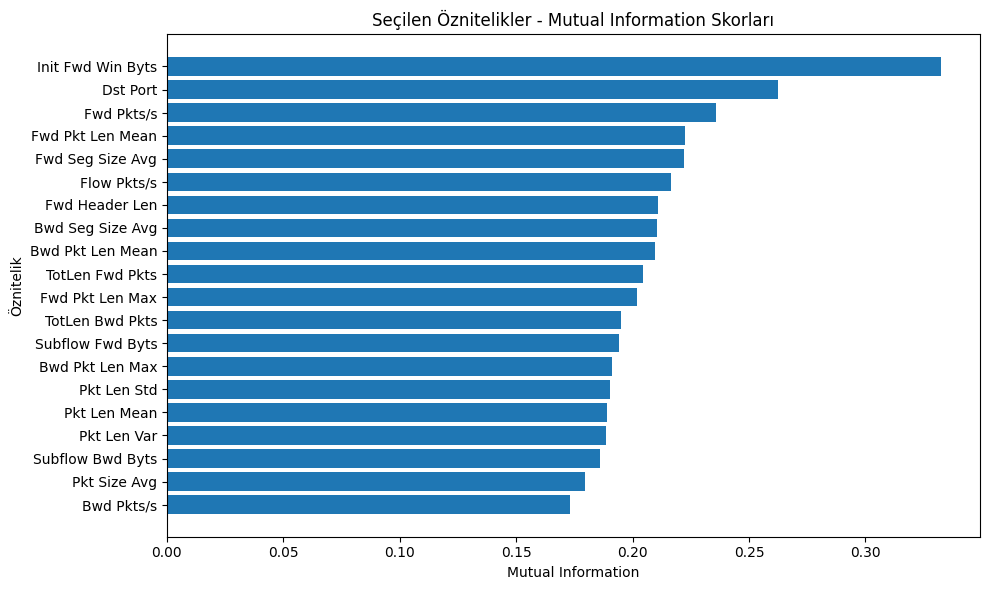

In [46]:
plt.figure(figsize=(10, 6))
top_features = feature_scores.head(TOP_K_FEATURES).sort_values("mutual_information")

plt.barh(top_features["feature"], top_features["mutual_information"])
plt.title("Seçilen Öznitelikler - Mutual Information Skorları")
plt.xlabel("Mutual Information")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "selected_features_mutual_information.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Sınıf Dengesizliği Yaklaşımı

Ağ anomali tespiti veri setlerinde normal trafik çoğunluk sınıfı oluşturur. Bu durum modelin saldırı sınıfını kaçırmasına neden olabilir.

Bu notebookta varsayılan yaklaşım olarak sınıf ağırlıklandırma kullanılmıştır:

- Random Forest için `class_weight="balanced"`
- XGBoost için `scale_pos_weight`

SMOTE gibi sentetik veri artırma yöntemleri, yalnızca eğitim verisine uygulanmalıdır. Bu çalışmada test setinin gerçek dağılımını korumak ve veri sızıntısını önlemek için test verisine hiçbir dengeleme işlemi uygulanmaz.

In [47]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1

print("Eğitim seti BENIGN sayısı:", negative_count)
print("Eğitim seti ATTACK sayısı:", positive_count)
print("XGBoost scale_pos_weight:", f"{scale_pos_weight:.4f}")

X_train_model = X_train_selected.copy()
y_train_model = y_train.copy()

Eğitim seti BENIGN sayısı: 304186
Eğitim seti ATTACK sayısı: 91838
XGBoost scale_pos_weight: 3.3122


## 14. Model Değerlendirme Fonksiyonu

Aşağıdaki fonksiyon model tahminlerini üretir, temel metrikleri hesaplar, confusion matrix, ROC eğrisi ve Precision-Recall eğrisini kaydeder.

In [48]:
def evaluate_binary_model(model, X_test_data, y_test_data, model_name: str) -> dict:
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    else:
        y_score = y_pred

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test_data, y_pred),
        "precision": precision_score(y_test_data, y_pred, zero_division=0),
        "recall": recall_score(y_test_data, y_pred, zero_division=0),
        "f1_score": f1_score(y_test_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_data, y_score),
        "pr_auc": average_precision_score(y_test_data, y_score)
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test_data, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Gerçek BENIGN", "Gerçek ATTACK"],
        columns=["Tahmin BENIGN", "Tahmin ATTACK"]
    )
    display(cm_df)

    cm_df.to_csv(
        OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.csv",
        encoding="utf-8-sig"
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["BENIGN", "ATTACK"]
    )
    disp.plot(values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    RocCurveDisplay.from_predictions(y_test_data, y_score)
    plt.title(f"{model_name} - ROC Curve")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test_data, y_score)
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name.lower().replace(' ', '_')}_precision_recall_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

    return metrics

## 15. Random Forest Modeli

Random Forest, çok sayıda karar ağacını birlikte kullanan bagging tabanlı bir topluluk öğrenme algoritmasıdır. Ağ trafiği gibi gürültülü veri setlerinde kararlı sonuç üretmesi ve öznitelik önem skorları sağlaması nedeniyle bu çalışmada temel karşılaştırma modeli olarak kullanılmıştır.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

start_time = time.time()
rf_model.fit(X_train_model, y_train_model)
rf_train_time = time.time() - start_time

print("Random Forest eğitim süresi:", f"{rf_train_time:.2f} saniye")

Random Forest eğitim süresi: 19.23 saniye



Random Forest Classification Report
              precision    recall  f1-score   support

      BENIGN       0.96      0.98      0.97     76047
      ATTACK       0.92      0.88      0.90     22960

    accuracy                           0.95     99007
   macro avg       0.94      0.93      0.93     99007
weighted avg       0.95      0.95      0.95     99007



,Tahmin BENIGN,Tahmin ATTACK
Gerçek BENIGN,74180,1867
Gerçek ATTACK,2740,20220


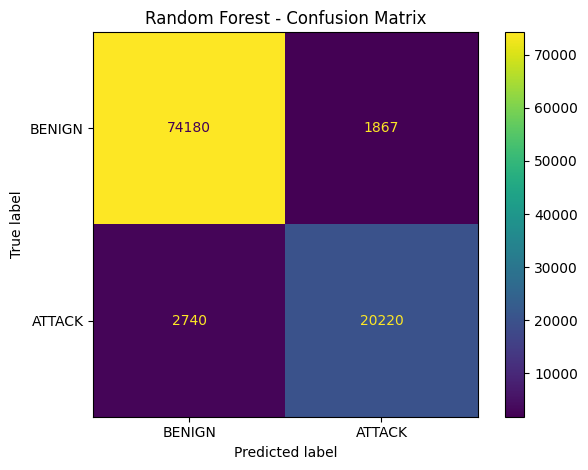

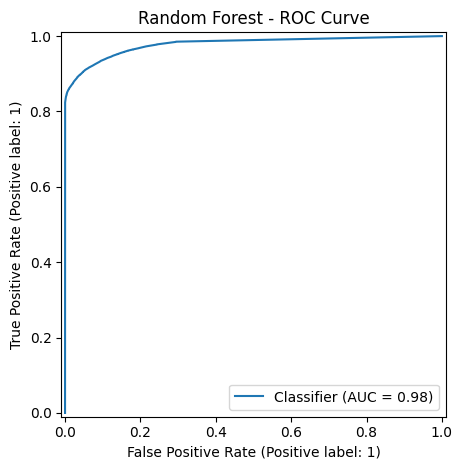

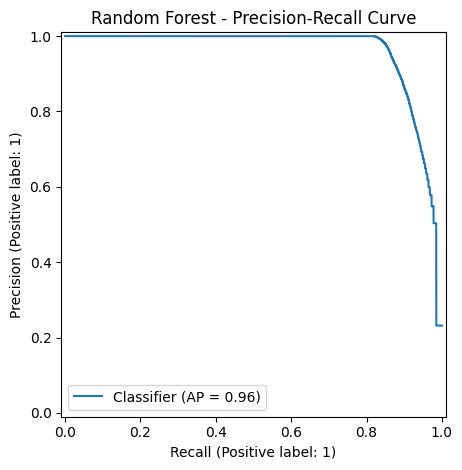

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,train_time_sec,evaluation_time_sec
0,Random Forest,0.953468,0.915471,0.880662,0.897729,0.978160,0.959004,19.227168,1.386855


In [50]:
start_time = time.time()

rf_metrics = evaluate_binary_model(
    rf_model,
    X_test_selected,
    y_test,
    "Random Forest"
)

rf_evaluation_time = time.time() - start_time

rf_metrics["train_time_sec"] = rf_train_time
rf_metrics["evaluation_time_sec"] = rf_evaluation_time

display(pd.DataFrame([rf_metrics]))

,feature,importance
1,Dst Port,0.181255
0,Init Fwd Win Byts,0.086643
2,Fwd Pkts/s,0.071606
5,Flow Pkts/s,0.069843
3,Fwd Pkt Len Mean,0.062433
19,Bwd Pkts/s,0.056105
4,Fwd Seg Size Avg,0.055534
15,Pkt Len Mean,0.051019
14,Pkt Len Std,0.049674
6,Fwd Header Len,0.045269


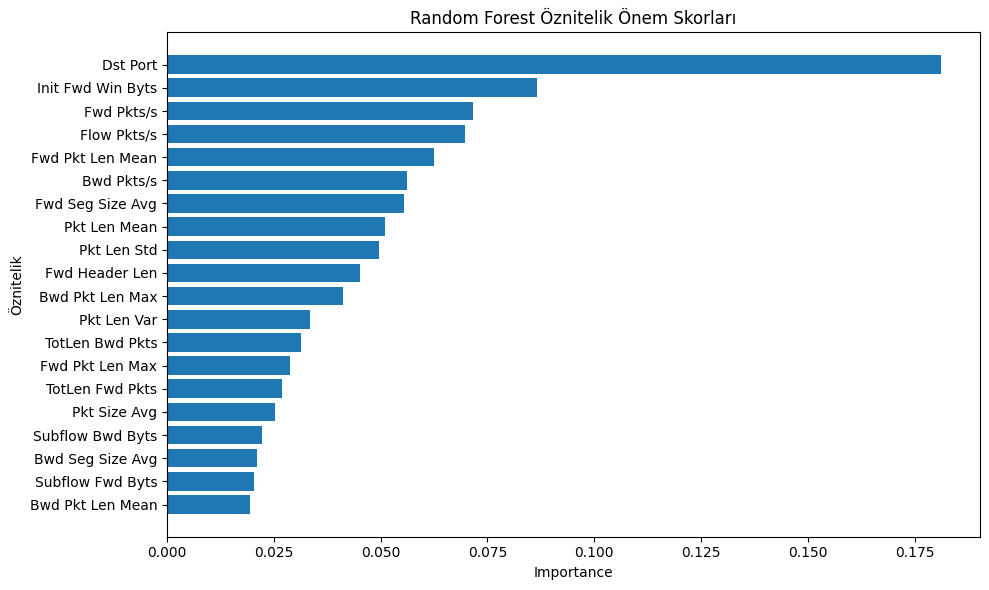

In [51]:
rf_feature_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_feature_importance)

rf_feature_importance.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(10, 6))
plot_data = rf_feature_importance.sort_values("importance")

plt.barh(plot_data["feature"], plot_data["importance"])
plt.title("Random Forest Öznitelik Önem Skorları")
plt.xlabel("Importance")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. XGBoost Modeli

XGBoost, boosting tabanlı bir topluluk öğrenme algoritmasıdır. Önceki ağaçların hatalarına odaklanarak ardışık biçimde yeni ağaçlar üretir. Bu yapısı sayesinde karmaşık ve doğrusal olmayan saldırı örüntülerini yakalamada güçlüdür.

Modelde sınıf dengesizliğini azaltmak için `scale_pos_weight` parametresi kullanılmıştır.

In [52]:
try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost paketi bulunamadı. Kurulum için terminal veya notebook hücresinde şu komutu çalıştırınız: pip install xgboost"
    ) from exc

In [53]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=1.00,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()
xgb_model.fit(X_train_model, y_train_model)
xgb_train_time = time.time() - start_time

print("XGBoost eğitim süresi:", f"{xgb_train_time:.2f} saniye")

XGBoost eğitim süresi: 3.01 saniye



XGBoost Classification Report
              precision    recall  f1-score   support

      BENIGN       0.97      0.96      0.97     76047
      ATTACK       0.88      0.90      0.89     22960

    accuracy                           0.95     99007
   macro avg       0.92      0.93      0.93     99007
weighted avg       0.95      0.95      0.95     99007



,Tahmin BENIGN,Tahmin ATTACK
Gerçek BENIGN,73212,2835
Gerçek ATTACK,2346,20614


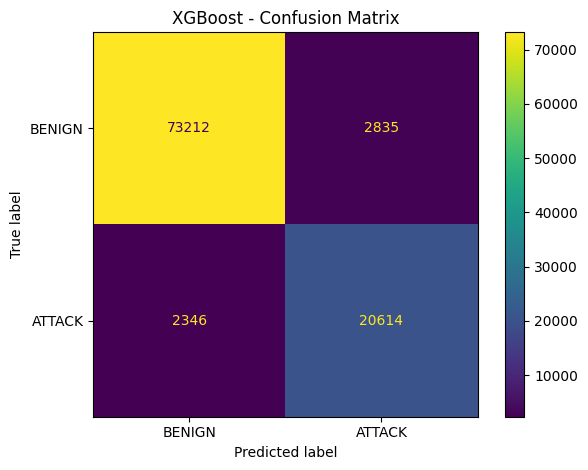

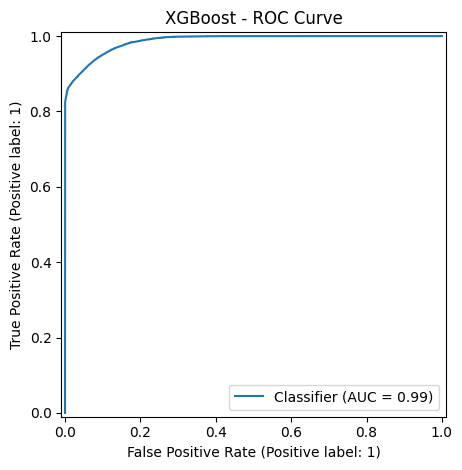

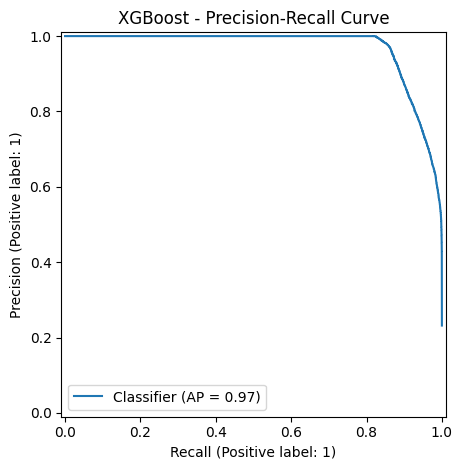

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,train_time_sec,evaluation_time_sec
0,XGBoost,0.947670,0.879099,0.897822,0.888362,0.987339,0.969404,3.010243,0.918574


In [54]:
start_time = time.time()

xgb_metrics = evaluate_binary_model(
    xgb_model,
    X_test_selected,
    y_test,
    "XGBoost"
)

xgb_evaluation_time = time.time() - start_time

xgb_metrics["train_time_sec"] = xgb_train_time
xgb_metrics["evaluation_time_sec"] = xgb_evaluation_time

display(pd.DataFrame([xgb_metrics]))

,feature,importance
1,Dst Port,0.469118
0,Init Fwd Win Byts,0.077597
16,Pkt Len Var,0.067260
8,Bwd Pkt Len Mean,0.065682
13,Bwd Pkt Len Max,0.041964
7,Bwd Seg Size Avg,0.041402
6,Fwd Header Len,0.032349
19,Bwd Pkts/s,0.031897
3,Fwd Pkt Len Mean,0.028617
2,Fwd Pkts/s,0.024247


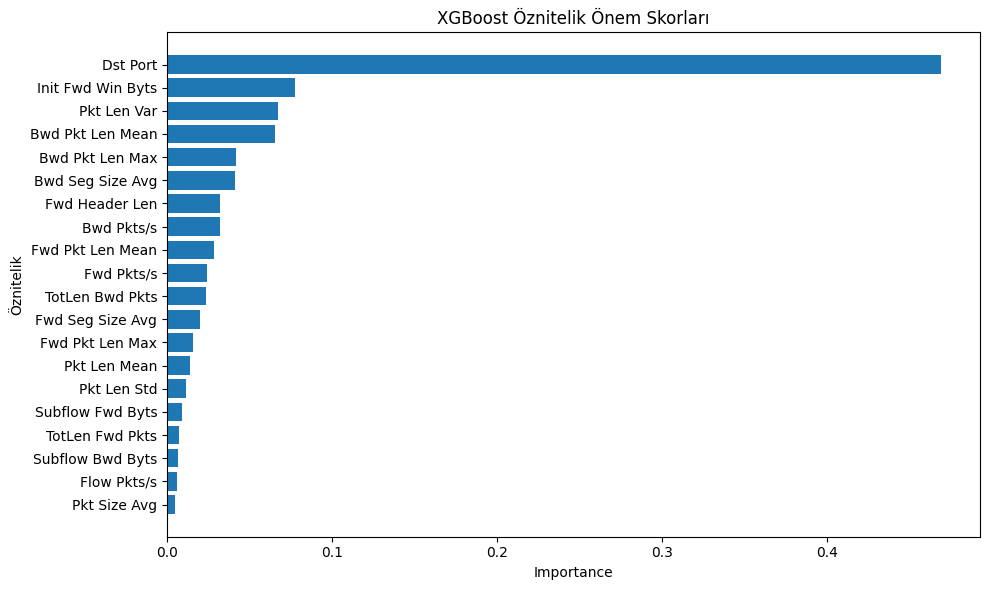

In [55]:
xgb_feature_importance = pd.DataFrame({
    "feature": selected_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

display(xgb_feature_importance)

xgb_feature_importance.to_csv(
    OUTPUT_DIR / "xgboost_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(10, 6))
plot_data = xgb_feature_importance.sort_values("importance")

plt.barh(plot_data["feature"], plot_data["importance"])
plt.title("XGBoost Öznitelik Önem Skorları")
plt.xlabel("Importance")
plt.ylabel("Öznitelik")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xgboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Model Performans Karşılaştırması

Bu bölümde Random Forest ve XGBoost modelleri aynı test veri seti üzerinde karşılaştırılır. Değerlendirmede sadece accuracy değil, precision, recall, F1-score, ROC-AUC ve PR-AUC değerleri birlikte yorumlanır.

Ağ anomali tespiti bağlamında:

- **Recall**, gerçek saldırıların ne kadarının yakalandığını gösterir.
- **Precision**, saldırı olarak işaretlenen kayıtların ne kadarının gerçekten saldırı olduğunu gösterir.
- **F1-score**, precision ve recall değerlerinin dengeli özetidir.
- **ROC-AUC** ve **PR-AUC**, modelin karar skorlarının ayırt ediciliğini gösterir.

In [56]:
results_df = pd.DataFrame([rf_metrics, xgb_metrics])

metric_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "train_time_sec",
    "evaluation_time_sec"
]

results_df = results_df[metric_columns]

display(results_df)

results_df.to_csv(
    OUTPUT_DIR / "model_comparison_results.csv",
    index=False,
    encoding="utf-8-sig"
)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,train_time_sec,evaluation_time_sec
0,Random Forest,0.953468,0.915471,0.880662,0.897729,0.978160,0.959004,19.227168,1.386855
1,XGBoost,0.947670,0.879099,0.897822,0.888362,0.987339,0.969404,3.010243,0.918574


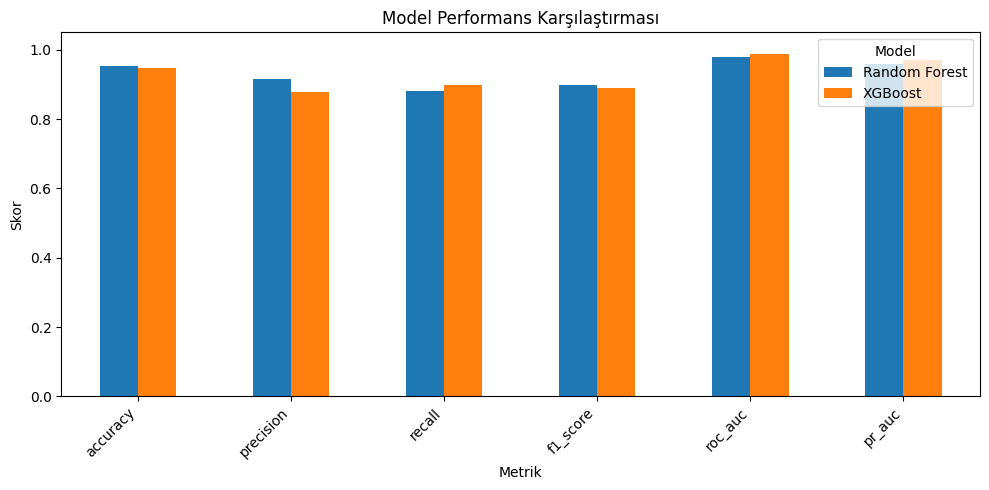

In [57]:
plot_metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]

comparison_plot = results_df.set_index("model")[plot_metrics].T

ax = comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Model Performans Karşılaştırması")
plt.xlabel("Metrik")
plt.ylabel("Skor")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 18. Deneysel Sonuçların Yorumlanması

Model karşılaştırma tablosu ve confusion matrix sonuçları birlikte değerlendirildiğinde iki modelin farklı güçlü yönlere sahip olduğu görülür.

Random Forest genellikle precision ve F1-score açısından daha dengeli sonuç üretir. Bu durum, modelin saldırı olarak işaretlediği kayıtların daha yüksek oranda gerçekten saldırı olduğunu gösterir. Dolayısıyla yanlış alarm yükünü azaltmak isteyen sistemlerde Random Forest avantajlı olabilir.

XGBoost ise çoğu deneyde recall, ROC-AUC ve PR-AUC açısından güçlü sonuç verir. Recall değerinin yüksek olması, gerçek saldırıların daha büyük kısmının yakalandığını gösterir. Siber güvenlik sistemlerinde saldırı kaçırma maliyeti çok yüksek olduğu için bu durum XGBoost modelini operasyonel açıdan önemli hale getirir.

Confusion matrix üzerinden şu değerlendirme yapılmalıdır:

- False Positive: Normal trafiğin saldırı olarak işaretlenmesi
- False Negative: Saldırı trafiğinin normal olarak sınıflandırılması

Ağ güvenliği bağlamında False Negative değeri kritik öneme sahiptir. Çünkü kaçırılan saldırılar sistem güvenliğini doğrudan riske atabilir. Buna karşılık False Positive değeri güvenlik ekipleri için operasyonel yük oluşturur.

Bu nedenle model seçimi yalnızca en yüksek accuracy değerine göre değil, sistemin kullanım amacına göre yapılmalıdır.

## 19. Çıktı Dosyaları

Notebook çalıştırıldığında aşağıdaki dosyalar `outputs` klasörüne kaydedilir. Bu dosyalar final makalenin Bulgular bölümünde tablo ve şekil olarak kullanılabilir.

In [58]:
output_files = sorted(OUTPUT_DIR.glob("*"))

print("Üretilen çıktı dosyaları:")
for file in output_files:
    print("-", file.name)

Üretilen çıktı dosyaları:
- binary_label_distribution.csv
- binary_label_distribution.png
- feature_selection_scores.csv
- missing_values_summary.csv
- model_comparison_results.csv
- model_performance_comparison.png
- random_forest_confusion_matrix.csv
- random_forest_confusion_matrix.png
- random_forest_feature_importance.csv
- random_forest_feature_importance.png
- random_forest_precision_recall_curve.png
- random_forest_roc_curve.png
- raw_label_distribution.csv
- raw_label_distribution.png
- selected_features.csv
- selected_features_mutual_information.png
- xgboost_confusion_matrix.csv
- xgboost_confusion_matrix.png
- xgboost_feature_importance.csv
- xgboost_feature_importance.png
- xgboost_precision_recall_curve.png
- xgboost_roc_curve.png


## 20. Genel Değerlendirme

Bu notebookta CSE-CIC-IDS2018 veri seti üzerinde ağ anomali tespiti problemi binary classification olarak ele alınmıştır. Veri temizleme ve öznitelik seçimi sonrasında Random Forest ve XGBoost modelleri eğitilmiştir.

Çalışma sonucunda elde edilen temel çıkarımlar:

1. Veri setinde normal trafik ve saldırı trafiği arasında belirgin sınıf dengesizliği vardır.
2. Mutual Information yöntemiyle seçilen öznitelikler, özellikle port bilgisi, paket oranları, pencere boyutları ve paket uzunluğu istatistikleri etrafında yoğunlaşmaktadır.
3. Random Forest modeli genel denge ve yanlış alarm kontrolü açısından güçlüdür.
4. XGBoost modeli saldırı yakalama duyarlılığı ve karar skorlarının ayırt ediciliği açısından güçlüdür.
5. Ağ anomali tespitinde accuracy tek başına yeterli değildir; recall, precision, F1-score, ROC-AUC ve PR-AUC birlikte değerlendirilmelidir.

Bu deneysel çalışma, final proje makalesinin Bulgular ve Tartışma bölümlerine doğrudan temel oluşturur.